In [ ]:
import json
from pathlib import Path

import numpy as np
from qiskit.primitives import BackendEstimatorV2
from qiskit_aer import AerSimulator

from plot_utils import (
    plot_depth_comparison,
    plot_energy_expectations,
    plot_residual_error,
    plot_vqe_convergence,
)
from simulation_utils import (
    build_ansatz,
    build_hardware_backend,
    build_molecule,
    build_molecule_hamiltonian_jw,
    export_results,
    run_experiment,
    run_vqe,
    transpile_for_hardware,
)

In [10]:
problem, qubit_op, mapper, nuclear_repulsion = build_molecule()
preview_ansatz = build_ansatz(problem, mapper, "HEA_RING", hea_layers=1)

In [11]:
(
    hamiltonian_jw,
    nuclear_repulsion,
    e_ground_elec,
    num_spatial_orbitals,
    num_particles,
    classical_shift,
) = build_molecule_hamiltonian_jw()

print(f"Spatial orbitals: {num_spatial_orbitals}")
print(f"Particles: {num_particles}")
print(f"Classical shift: {classical_shift:.6f} Ha")

Molecule:                            H 0 0 0; H 0 0 0.735
Basis:                               sto3g
Qubits (JW mapping):                 4
Spatial orbitals:                    2
Electrons (alpha, beta):             (1, 1)
Exact Electronic Ground Energy:      -1.857275 Ha
Exact Total Ground State Energy:     -1.137306 Ha
classical shift (Hamiltonian constant terms): 0.719969 Ha
Spatial orbitals: 2
Particles: (1, 1)
Classical shift: 0.719969 Ha


In [12]:
estimator = BackendEstimatorV2(backend=AerSimulator())
_, coupling_map, basis_gates = build_hardware_backend(
    "ion_trap",
    num_qubits=hamiltonian_jw.num_qubits,
    p1q_error=0.0,
    p2q_error=0.0,
    shots=8192,
)

transpiled_ansatz, transpiled_obs = transpile_for_hardware(
    preview_ansatz,
    hamiltonian_jw,
    coupling_map,
    basis_gates,
)

In [13]:
methods = ["COBYLA"]
results = {}

np.random.seed(42)
initial_params = np.random.uniform(-np.pi, np.pi, preview_ansatz.num_parameters)

In [ ]:
for method in methods:
    result, history = run_vqe(
        estimator,
        transpiled_ansatz,
        transpiled_obs,
        nuclear_repulsion,
        initial_params,
        method,
        maxiter=200,
    )
    results[method] = {
        "fun": result.fun,
        "x": result.x,
        "estimator_log": history,
    }

    print(f"Method: {method}")
    print(f"VQE Total Energy: {result.fun:.4f} Ha")

Method: COBYLA
VQE Electronic Energy: -1.2543 Ha
VQE Total Energy: -0.5343 Ha



In [ ]:
results = run_experiment(
    molecule="H2",
    ansatz_type="HEA_RING",
    hea_layers=2,
    optimizers=("COBYLA", "SLSQP", "NFT"),
    fci_energy=-1.1373,
    maxiter=40,
    shots=8192,
    p1q_error=0.001,
    p2q_error=0.03,
)

export_path = export_results(
    results,
    molecule="H2",
    ansatz="HEA",
    filename="HEA_H2_analytics.json",
)

print(f"Saved HEA analytics to {export_path}")

Running Ideal Baseline (No Noise)...
Running Ion Trap with COBYLA...
Running Superconducting with COBYLA...
Running Ion Trap with SLSQP...
Running Superconducting with SLSQP...
Running Ion Trap with NFT...
Running Superconducting with NFT...

Success! HEA Data locked away safely in data/H2/HEA_H2_analytics.json


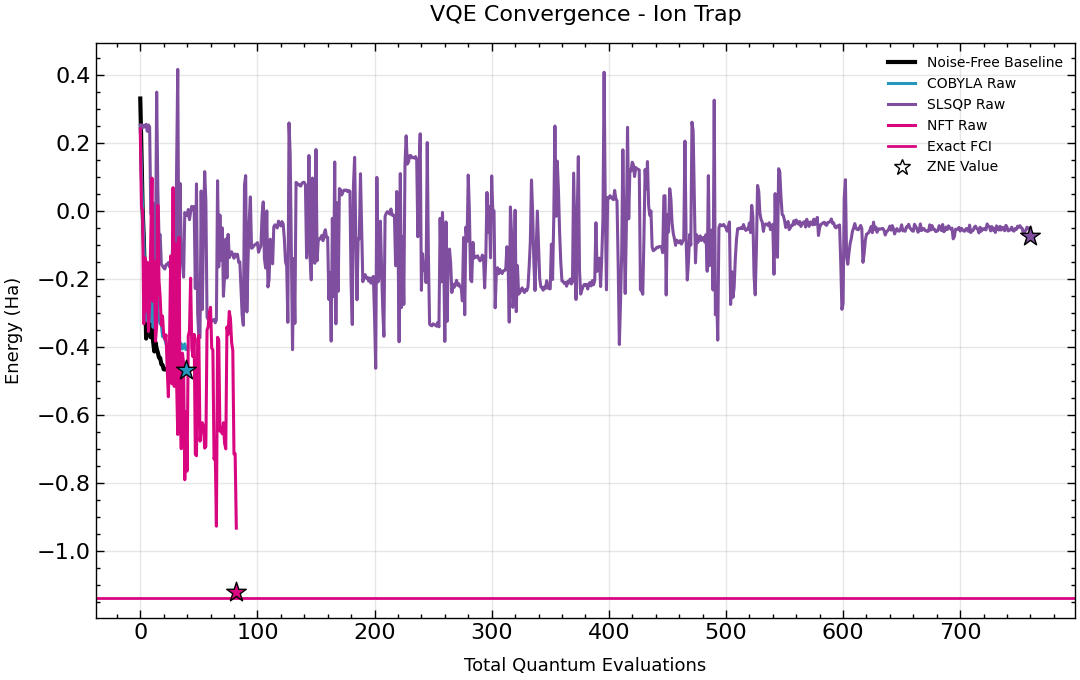

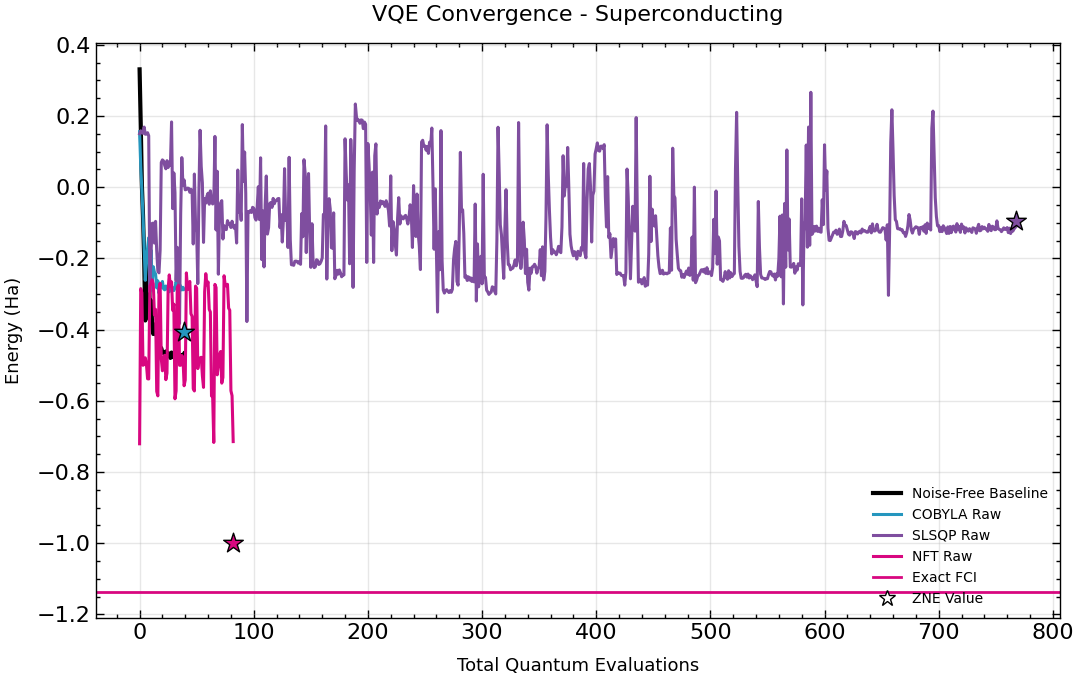

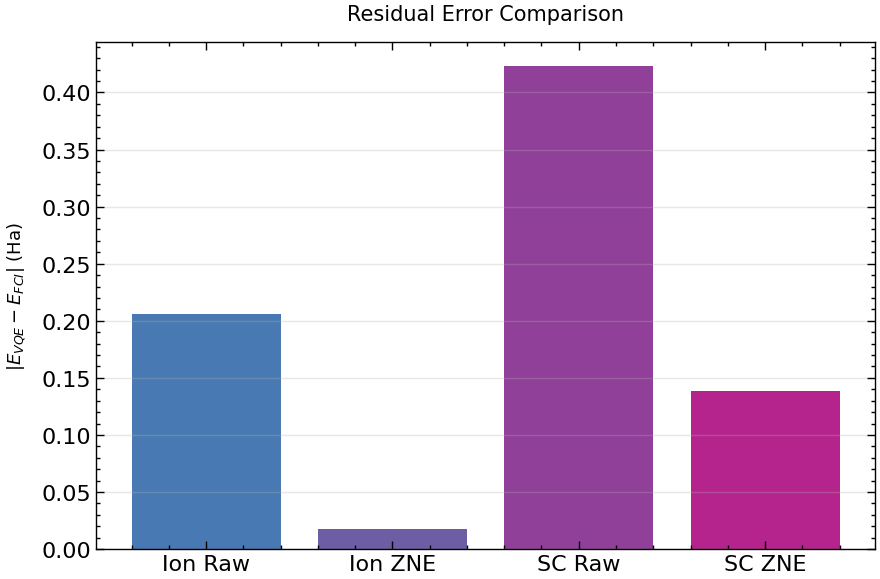

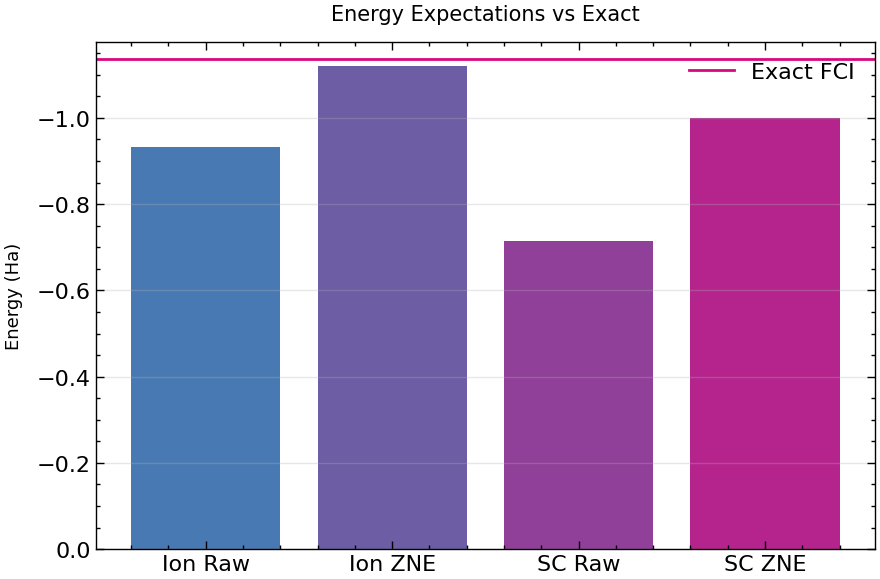

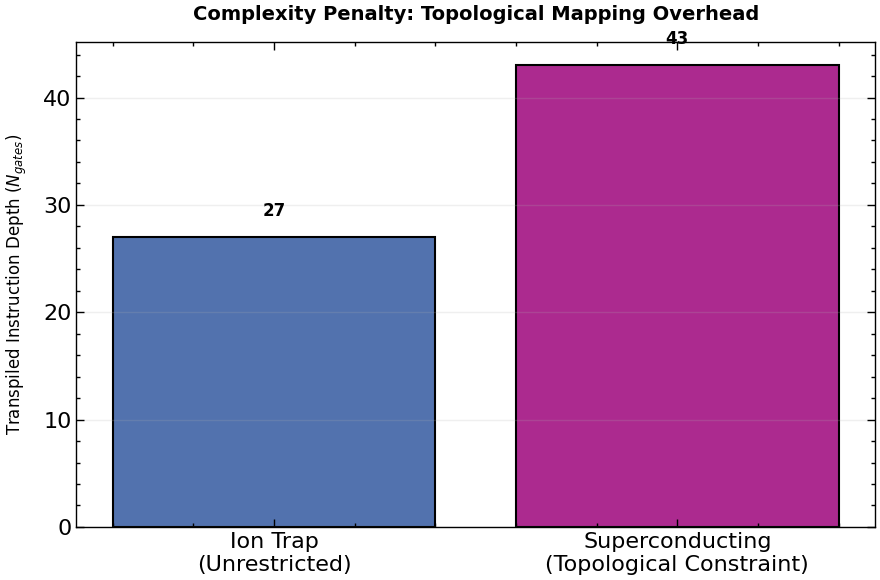

In [ ]:
file_path = Path("data/H2/HEA_H2_analytics.json")

with open(file_path, "r") as f:
    data = json.load(f)

fci_energy = data["fci_energy"]
ideal_hist = data["ideal_history"]
ion_data = data["ion_data"]
sc_data = data["sc_data"]
depths = data["depths"]

plot_vqe_convergence(ion_data, ideal_hist, fci_energy, "Ion Trap")
plot_vqe_convergence(sc_data, ideal_hist, fci_energy, "Superconducting")
plot_residual_error(ion_data, sc_data, fci_energy, optimizer="NFT")
plot_energy_expectations(ion_data, sc_data, fci_energy, optimizer="NFT")
plot_depth_comparison(depths)